## 1. Imports and Setup

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 2. Load Processed Dataset

In [16]:
processed_tracks = pd.read_csv(
    "../data/processed/scaled_audio_features.csv"
)

processed_tracks.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity,track_name,track_id
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717,Blood,5qljLQuKnNJf4F4vfxQB0V
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047,The Ugly Duckling,3VAX2MJdmdqARLSU5hPMpm
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047,Jimmy Launches His Own Range Of Greetings Cards,1L3YAhsEMrGVvCgDXj2TYn
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513,The Crime At Pickets Mill,6aCe9zzoZmCojX7bbgKKtf
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490,Setup + Punchline = Joke,1Vo802A38tPFHmje1h91um


## 3. Dataset Overview

In [17]:
processed_tracks.shape

(101939, 13)

In [18]:
processed_tracks.columns

Index(['acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence',
       'duration_ms', 'popularity', 'track_name', 'track_id'],
      dtype='object')

In [19]:
processed_tracks.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity,track_name,track_id
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717,Blood,5qljLQuKnNJf4F4vfxQB0V
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047,The Ugly Duckling,3VAX2MJdmdqARLSU5hPMpm
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047,Jimmy Launches His Own Range Of Greetings Cards,1L3YAhsEMrGVvCgDXj2TYn
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513,The Crime At Pickets Mill,6aCe9zzoZmCojX7bbgKKtf
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490,Setup + Punchline = Joke,1Vo802A38tPFHmje1h91um


## 4. Define Feature Columns

In [20]:
feature_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "duration_ms",
    "popularity"
]

## 5. Create Feature Matrix

In [21]:
X = processed_tracks[feature_cols]

X.shape

(101939, 11)

## 6. Compute Cosine Similarity Matrix

In [22]:
sample_df = processed_tracks.sample(
    n=5000,
    random_state=42
).reset_index(drop=True)

X_sample = sample_df[feature_cols]

In [23]:
similarity_matrix = cosine_similarity(X_sample)

similarity_matrix.shape

(5000, 5000)

## 7. Similarity Distribution

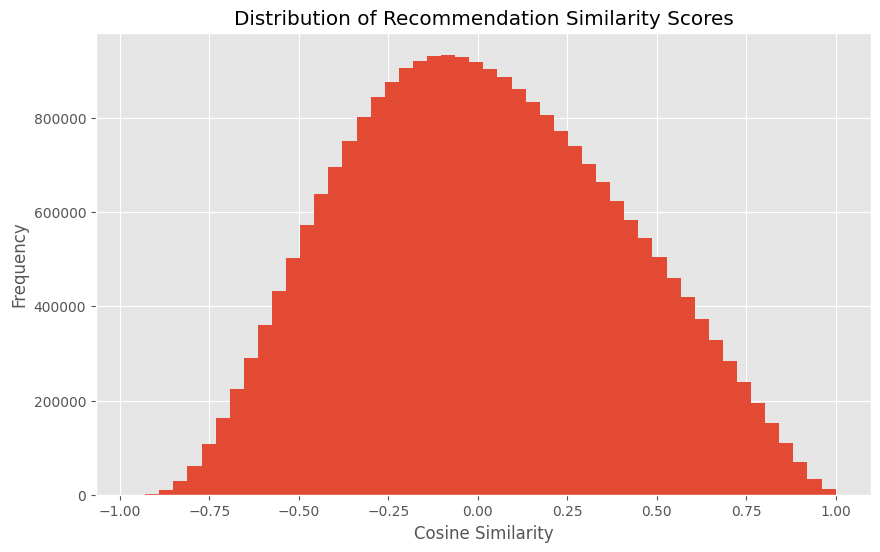

In [24]:
similarity_scores = similarity_matrix.flatten()

plt.figure(figsize=(10, 6))

plt.hist(similarity_scores, bins=50)

plt.title("Distribution of Recommendation Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")

plt.show()

## 8. Recommendation Function

In [25]:
def recommend_tracks(track_name, df, similarity_matrix, n_recommendations=5):

    matches = df[df["track_name"].str.lower() == track_name.lower()]

    if len(matches) == 0:
        print("Track not found.")
        return None

    idx = matches.index[0]

    similarity_scores = list(enumerate(similarity_matrix[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n_recommendations + 1]

    recommendations = []

    for i, score in similarity_scores:

        recommendations.append({
            "track_name": df.iloc[i]["track_name"],
            "similarity_score": score,
            "popularity": df.iloc[i]["popularity"]
        })

    return pd.DataFrame(recommendations)

## 9. Test Recommendations

In [26]:
sample_df["track_name"].sample(10, random_state=42)

1501             Zusammen feat. Clueso
2586                       Sick wid It
2653                      Memphis Rain
1055                 Leaving Los Feliz
705     Why Does It Always Rain on Me?
106                     Guns and Ships
589                           Nti Galb
2468     Recuerdos de Calahuayo (Peru)
2413          Världens lyckligaste par
1600                         Dump Dump
Name: track_name, dtype: object

In [27]:
recommend_tracks(
    "Billie Jean",
    sample_df,
    similarity_matrix
)

,track_name,similarity_score,popularity
0,Stand By Your Man,0.941064,1.263658
1,Did Not Our Hearts Burn,0.939207,0.906317
2,Secreto De Amor,0.926286,1.561442
3,Tomorrow,0.925912,1.740113
4,Per uno come me,0.916408,1.501885


## 10. Recommendation Diversity Analysis

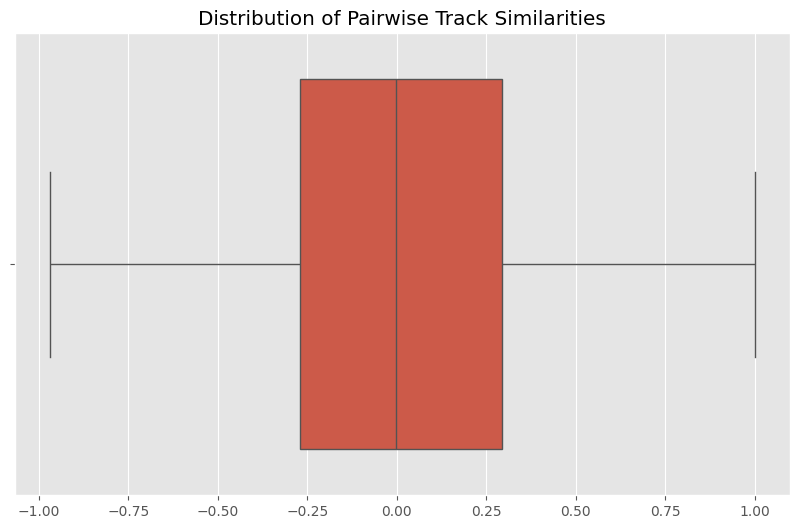

In [28]:
top_similarity = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

plt.figure(figsize=(10, 6))

sns.boxplot(x=top_similarity)

plt.title("Distribution of Pairwise Track Similarities")

plt.show()

## 11. Most Similar Track Pairs

In [29]:
upper_triangle = np.triu_indices_from(similarity_matrix, k=1)

scores = similarity_matrix[upper_triangle]

top_n = 10
top_indices = np.argsort(scores)[-top_n:][::-1]

top_pairs = []

for idx in top_indices:
    i = upper_triangle[0][idx]
    j = upper_triangle[1][idx]

    top_pairs.append({
        "track_1": sample_df.iloc[i]["track_name"],
        "track_2": sample_df.iloc[j]["track_name"],
        "similarity": scores[idx]
    })

top_pairs_df = pd.DataFrame(top_pairs)

top_pairs_df

,track_1,track_2,similarity
0,Kaban no Naka no Yakimochi,鞄の中のやきもち,1.000000
1,The Call of Cthulhu - Part 1 By HP Lovecraft,The Call Of Cthulhu - Part 2,0.999578
2,Easily,Easily,0.998881
3,Health and Emergency Vocabulary in Arabic,Daily Routine Activities in Arabic,0.998028
4,"Valse lente, Op. 33: Valse Lente, Op. 33",Angelical,0.997063
5,Loren Gray - Some of my Favorite Songs and Art...,Loren Gray - Intro,0.996750
6,on a tuesday,"6 Piano Pieces, Op. 26: No. 2, Pastoral Atmosp...",0.996402
7,The Call of Cthulhu - Part 1 By HP Lovecraft,The Premature Burial,0.996202
8,"Peer Gynt Suite No. 1, Op. 46: Morning Mood - ...",For All We Know,0.995552
9,Relaxamento,London 1998,0.995213


In [33]:
top_pairs = pd.DataFrame(top_pairs)

top_pairs.sort_values(
    by="similarity",
    ascending=False
).head(10)

,track_1,track_2,similarity
0,Kaban no Naka no Yakimochi,鞄の中のやきもち,1.000000
1,The Call of Cthulhu - Part 1 By HP Lovecraft,The Call Of Cthulhu - Part 2,0.999578
2,Easily,Easily,0.998881
3,Health and Emergency Vocabulary in Arabic,Daily Routine Activities in Arabic,0.998028
4,"Valse lente, Op. 33: Valse Lente, Op. 33",Angelical,0.997063
5,Loren Gray - Some of my Favorite Songs and Art...,Loren Gray - Intro,0.996750
6,on a tuesday,"6 Piano Pieces, Op. 26: No. 2, Pastoral Atmosp...",0.996402
7,The Call of Cthulhu - Part 1 By HP Lovecraft,The Premature Burial,0.996202
8,"Peer Gynt Suite No. 1, Op. 46: Morning Mood - ...",For All We Know,0.995552
9,Relaxamento,London 1998,0.995213


## 12. Save Baseline Recommendation Dataset

In [34]:
sample_df.to_csv(
    "../data/processed/recommender_sample.csv",
    index=False
)

print("Baseline recommender dataset saved.")

Baseline recommender dataset saved.


# Final Interpretation

The baseline recommender successfully generates recommendations using cosine similarity on scaled Spotify audio features.

The similarity score distributions show that most randomly selected track pairs are not extremely similar, while a smaller number of pairs reach very high similarity values. This suggests that the selected features are able to separate tracks in the feature space.

The recommendation function also works as a first prototype. For a selected track, it returns songs with similar numerical audio profiles based on features such as danceability, energy, acousticness, tempo, valence, duration, and popularity.

However, the results also reveal important limitations. Some highly similar pairs are duplicate versions of the same song, translated titles, audiobook chapters, language-learning tracks, or spoken-word content. This confirms that the dataset contains more than only standard music tracks.

Therefore, this baseline should be understood as an audio-feature-based recommender, not yet as a fully polished music recommender. For future versions, additional filtering and metadata features should be included to improve recommendation quality.

Possible improvements include:
- filtering out spoken-word and audiobook content
- adding artist or genre information
- avoiding duplicate or near-duplicate track recommendations
- using approximate nearest neighbors for better scalability
- combining audio features with lyrics or playlist context

Overall, the baseline recommender provides a useful first model and confirms that the project pipeline works end-to-end.